# NExT-Guard Stage 2: Filter, Combination & Calibration (Updated)

This notebook simulates the streaming safeguard offline to calibrate the optimal intervention threshold.
**Update**: Optimized for PyTorch sparse tensor data format.

1. Load cached SAE activations (`torch.sparse_coo_tensor`).
2. Load identified safety features and weights ($s_j$) from Step 1.
3. Compute token-level risk scores: $c_t = \sum s_j \cdot v_j(y_t)$.
4. Determine the optimal threshold $\gamma$ to maximize F1 score.

In [1]:
import os
import yaml
import json
import torch
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve, f1_score
from dotenv import load_dotenv
load_dotenv()

from sae_tools.data_loader import get_adapter
from sae_tools.model import filter_data_by_label

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

/NAS/chennc/anaconda3/envs/nextguard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Configuration ---
BASE_DIR = Path.cwd()
MODEL_ROOT = os.getenv("MODEL_ROOT")
DATASET_ROOT = os.getenv("DATASET_ROOT")

INPUT_DIR = BASE_DIR / "results/Guard_Qwen3-8B_20260206_1005"
FEATURES_FILE = INPUT_DIR / "safety_features.json"
PT_DIR = INPUT_DIR / "predictions"

# Calibration Dataset
DATASET_NAME = "Aegis1.0" 
PT_FILE = PT_DIR / f"{DATASET_NAME}.pt"

print(f"Loading features from: {FEATURES_FILE}")
print(f"Loading activations from: {PT_FILE}")

Loading features from: /NAS/chennc/NashChennc/NExTGuard/results/Guard_Qwen3-8B_20260206_1005/safety_features.json
Loading activations from: /NAS/chennc/NashChennc/NExTGuard/results/Guard_Qwen3-8B_20260206_1005/predictions/Aegis1.0.pt


In [3]:
# 1. Load Safety Features
with open(FEATURES_FILE, 'r') as f:
    feature_map = json.load(f)

# We need to map feature indices to a dense weight vector for efficient matrix multiplication
# But since features are sparse (e.g. index 9249), we will construct a sparse weight vector or map indices during computation.
# Given Top-K is small (e.g. 32), we can just store them as pairs.
safety_indices = np.array([int(k) for k in feature_map.keys()])
safety_weights = np.array([float(v) for v in feature_map.values()])

print(f"Loaded {len(safety_indices)} safety features.")

Loaded 32 safety features.


In [5]:
# 2. Load Data (Torch Sparse Format)
print(f"Loading tensor data from {PT_FILE}...")
data_dict = torch.load(PT_FILE, map_location='cpu')

# Extract components
sparse_acts = data_dict['sparse_acts'] # torch.sparse_coo_tensor
valid_token_idx = data_dict['valid_token_idx'].numpy() # [N, 2]
seq_lens = data_dict['seq_lens'].numpy() # [N]

# Convert torch sparse COO to scipy CSR for efficient slicing
# Scipy CSR is much faster for row slicing than Torch COO
print("Converting to Scipy CSR matrix...")
indices = sparse_acts.indices().numpy()
values = sparse_acts.values().float().numpy()
shape = sparse_acts.shape

X_csr = sp.csr_matrix((values, (indices[0], indices[1])), shape=shape)

print(f"Activation matrix shape: {X_csr.shape}")

Loading tensor data from /NAS/chennc/NashChennc/NExTGuard/results/Guard_Qwen3-8B_20260206_1005/predictions/Aegis1.0.pt...
Converting to Scipy CSR matrix...
Activation matrix shape: (192432, 65536)


In [6]:
# 3. Load Metadata & Ground Truth
num_samples = len(seq_lens)
adapter = get_adapter(DATASET_NAME)

DATASETS_CONFIG = BASE_DIR / "configs/datasets/datasets_prompt.yaml"
with open(DATASETS_CONFIG, 'r') as f:
    ds_conf = yaml.safe_load(f)
folder = next(d['folder'] for d in ds_conf['datasets'] if d['name'] == DATASET_NAME)
DATASET_PATH = os.path.join(DATASET_ROOT, folder)

dataset = adapter.load(DATASET_PATH, num_samples)
metadata_list = [item for item in dataset]

LABEL_TYPE = "prompt_label" if "prompt" in str(DATASETS_CONFIG) else "response_label"
ground_truth = []

# Filter labels (Safe/Unsafe -> 0/1)
for i, item in enumerate(metadata_list):
    label = item.get(LABEL_TYPE)
    ground_truth.append(1 if label == 'Unsafe' else 0)

ground_truth = np.array(ground_truth)
print(f"Ground truth: {sum(ground_truth)} Unsafe / {len(ground_truth)} Total")

Map: 2398 examples [00:00, 10906.30 examples/s]        

Ground truth: 797 Unsafe / 1199 Total


In [7]:
# 4. Compute Max Risk Scores
# Logic: For each sample, extract valid tokens -> calculate risk score -> take max

max_scores = []
global_ptr = 0

# Construct a sparse weight vector for dot product
# Dimension: [num_features, 1]
num_features = X_csr.shape[1]
W_sparse = sp.csr_matrix(
    (safety_weights, (safety_indices, np.zeros_like(safety_indices))),
    shape=(num_features, 1)
)

print("Computing risk scores for all samples...")
for i in tqdm(range(num_samples)):
    # 1. Determine the row range for this sample's VALID tokens
    # valid_token_idx[i] = [start_relative, end_relative]
    start_rel, end_rel = valid_token_idx[i]
    
    # Absolute row indices in the flattened matrix
    abs_start = global_ptr + start_rel
    abs_end = global_ptr + end_rel
    
    # Update global pointer for next sample
    global_ptr += seq_lens[i]
    
    # 2. Slice the matrix (Get valid tokens)
    # Check if range is valid
    if abs_end > abs_start:
        tokens_csr = X_csr[abs_start:abs_end]
        
        # 3. Calculate Scores: tokens_csr @ weights
        # Result shape: [num_tokens, 1]
        token_scores = tokens_csr.dot(W_sparse)
        
        # 4. Max Score for this sample
        if token_scores.nnz > 0:
            max_score = token_scores.max()
        else:
            max_score = 0.0
    else:
        max_score = 0.0
        
    max_scores.append(max_score)

max_scores = np.array(max_scores)

Computing risk scores for all samples...


100%|██████████| 1199/1199 [00:00<00:00, 3027.75it/s]


Best F1: 0.8623
Optimal Threshold: 0.7879


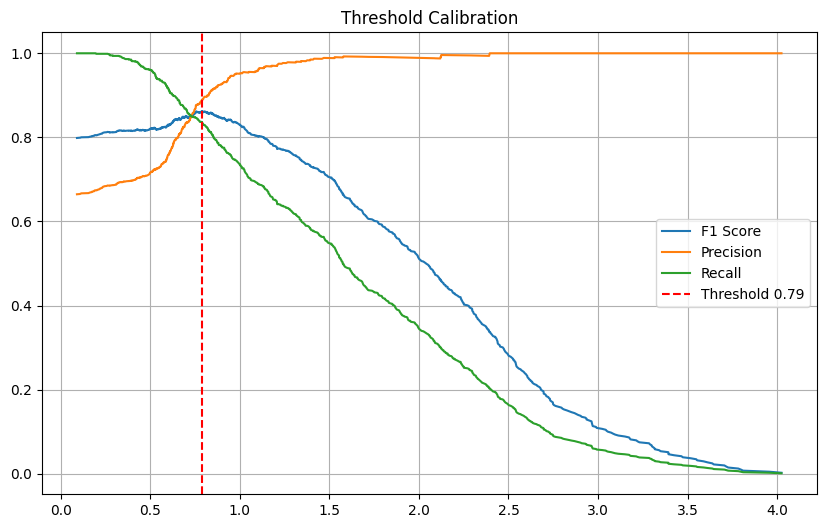

In [8]:
# 5. Threshold Optimization
precisions, recalls, thresholds = precision_recall_curve(ground_truth, max_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best F1: {best_f1:.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score')
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Threshold {best_threshold:.2f}')
plt.title('Threshold Calibration')
plt.legend()
plt.grid(True)
plt.savefig(INPUT_DIR / "threshold_calibration.png")
plt.show()

In [9]:
# 6. Save Config
config_export = {
    "threshold": float(best_threshold),
    "features": feature_map,
    "calibration_dataset": DATASET_NAME,
    "best_f1_cal": float(best_f1)
}
config_path = INPUT_DIR / "intervention_config.json"
with open(config_path, 'w') as f:
    json.dump(config_export, f, indent=4)
print(f"Saved config to {config_path}")

Saved config to /NAS/chennc/NashChennc/NExTGuard/results/Guard_Qwen3-8B_20260206_1005/intervention_config.json
